# <center>**Resultados**:<br>Código que estuda as equações de Maxwell-Bloch<br>Por meio das equações de Lorenz<center>


Este código gera gráficos para anális do seguinte sistema dinâmico:

$$\begin{equation}
	\begin{array}{l}
		\dot{X} = \sigma (Y - X),\\[.4cm]
		\dot{Y} = X(r - Z) - Y,\\[.4cm]
		\dot{Z} = XY - bZ.
	\end{array}
\end{equation}$$

As equações acima descrevem um sistema laser a partir das equações de Maxwell-Bloch transformadas no sistema de Lorenz conforme demonstrou (HAKEN, 1975). No TCC, esse código está referenciado como *"Código 02"*. O código recebe os parâmetros $\sigma$, $b$ e $r$. No TCC, utilizamos os parâmetros do laser de amônia (NH$_3$) para gerar as análises numéricas, os parâmetros são:

$$\begin{equation}
	\begin{array}{l}
        \sigma = 2.0 \times 10^2,\\[.4cm]
        r = 15,\\[.4cm]
		b = 0.25.
	\end{array}
\end{equation}$$

## **01.** Bibliotecas importadas e suas configurações

**Versão:** 1.1<br>
**Data de criação:** 04/02/2026<br>
**Criado por:** Jimi (Willian Bonner)<br>

In [1]:
# comandos para deixar as imagens com fonte Times (fonte de gente normal)
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import warnings
import sympy as sy
from gravipy.tensorial import *
import math
from IPython.display import display, Math, Latex
warnings.filterwarnings('ignore')

# Configuração do LaTeX
plt.rcParams.update({"text.usetex": True, "font.family": "serif","font.serif": ["Times"],
                     "text.latex.preamble":
                     r"""\usepackage{amsmath}
                     \usepackage{amssymb}
                     \usepackage{physics}
                     \usepackage{times}"""})

print('='*80)
display(Math(r'\LaTeX\ está\ ativo!'))
print('='*80)

<IPython.core.display.Math object>

## **02.** Análise numérica do sistema

Esta parte do código recebe os parâmetros de entrada e analisa o sistema dinâmico.

In [17]:
# ============================================================================
# Código para receber os parâmetros do sistema de Lorenz e analisar-lo
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Versão 2.0 
#   > Correção do cálculo do coeficiente de Lyapunov - 13/02/2026
# ============================================================================


# ============================================================================
# Código para receber os parâmetros do sistema de Lorenz e analisá-lo
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Versão 2.1
#   > Correção do cálculo do coeficiente de Lyapunov - 13/02/2026
#   > Armazenamento da convergência para plotagem - 19/02/2026
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import Matrix, symbols
from IPython.display import display, Math   # Para exibição em notebooks

# ============================================================================
# 1. Parâmetros de entrada
print("="*80 + '\n')
print("Para análise completa do sistema de Lorenz, digite os parâmetros de entrada\n")
print("=" *80)

# 1.1 Parâmetros padrão (clássicos)
sigma = float(input("Digite σ (padrão 10): ") or 10)
r = float(input("Digite r (padrão 28): ") or 28)
b = float(input("Digite b (padrão 2.667): ") or 2.667)

# 1.2. Exibir como em LaTeX
display(Math(fr'\sigma = {sigma:.3f}'))
display(Math(fr'r = {r:.3f}'))
display(Math(fr'b = {b:.3f}'))

# ============================================================================
# 2. Determinando os pontos fixos
print("\n" + "=" * 70)
print("2. Pontos fixos")
print("=" * 70)

# 2.1 Ponto fixo trivial
pontos_fixos = [(0, 0, 0)]

# 2.2 Pontos não triviais (se r > 1)
if r > 1:
    x = np.sqrt(b * (r - 1))
    z = r - 1
    pontos_fixos.append((x, x, z))
    pontos_fixos.append((-x, -x, z))

for i, pf in enumerate(pontos_fixos):
    display(Math(rf"P_{i}: ({pf[0]:.4f}, {pf[1]:.4f}, {pf[2]:.4f})"))

# ============================================================================
# 3. Matriz jacobiana (simbólica)
print("\n" + "=" * 80)
print("3. Matriz Jacobiana")
print("=" * 80)

x, y, z = symbols('x y z')
J_sym = Matrix([[-sigma, sigma, 0],
                [r - z, -1, -x],
                [y, x, -b]])
display(J_sym)

# ============================================================================
# 4. Classificar os pontos fixos e estabilidade
print("\n" + "=" * 70)
print("4. Classificação dos pontos fixos")
print("=" * 70)

def jacobiana(x, y, z):
    """Retorna a matriz Jacobiana do sistema de Lorenz (numérica)"""
    A = [[-sigma, sigma, 0],
         [r - z, -1, -x],
         [y, x, -b]]
    return np.array(A)

for i, pf in enumerate(pontos_fixos):
    xp, yp, zp = pf
    J = jacobiana(xp, yp, zp)
    autovalores = np.linalg.eigvals(J)
    
    # Classificação
    reais = autovalores.real
    imaginarios = autovalores.imag
    
    # Verificar estabilidade
    estavel = all(reais < 0)
    instavel = any(reais > 0)
    
    # Tipo do ponto
    if all(np.abs(imaginarios) < 1e-10):
        tipo = "Nó"
    elif any(np.abs(imaginarios) > 1e-10):
        tipo = "Espiral"
    
    if estavel:
        tipo += " estável"
    elif instavel:
        tipo += " instável"
    
    # Exibir autovalores formatados
    av_str = []
    for av in autovalores:
        real = av.real
        imag = av.imag
        if np.abs(imag) < 1e-10:
            av_str.append(f"{real:.4f}")
        else:
            sinal = "+" if imag >= 0 else "-"
            av_str.append(f"{real:.4f}{sinal}{np.abs(imag):.4f}i")
    
    display(Math(rf"P_{i}: \quad \lambda = [{', '.join(av_str)}]"))
    print(f'Classificação: {tipo}')
    print('='*70)

# ============================================================================
# 5. Determinar a caoticidade do sistema – EXPOENTE DE LYAPUNOV (Benettin)
print("\n" + "=" * 80)
print("5. Cálculo do maior expoente de Lyapunov (método de Benettin)")
print("=" * 80)

# 5.1 Definir o sistema do tipo Lorenz
def lorenz(t, estado):
    x, y, z = estado
    dx = sigma * (y - x)
    dy = x * (r - z) - y
    dz = x * y - b * z
    return [dx, dy, dz]

# 5.2 Parâmetros para o cálculo de Lyapunov
T_transiente = 100.0   # tempo para a trajetória atingir o atrator
T_integracao = 200.0   # tempo total de coleta de dados
dt = 0.1               # passo de tempo entre renormalizações
eps = 1e-8             # norma inicial do vetor perturbação

# 5.3 Condição inicial e perturbação
x0 = np.array([1.0, 1.0, 1.0])
np.random.seed(42)     # para reprodutibilidade
delta0 = np.random.randn(3)
delta0 = eps * delta0 / np.linalg.norm(delta0)

# ---- Fase de transiente: levar a trajetória para o atrator ----
t_trans = np.linspace(0, T_transiente, int(T_transiente/dt)+1)
sol_trans = solve_ivp(lorenz, [0, T_transiente], x0, t_eval=t_trans, rtol=1e-8, atol=1e-10)
x0 = sol_trans.y[:, -1]   # estado final da fase transiente

# ---- Fase de coleta: cálculo do expoente de Lyapunov ----
t = 0.0
x = x0.copy()
delta = delta0.copy()
lyap_sum = 0.0
n_passos = int(T_integracao / dt)

# Listas para armazenar a convergência
tempos_lyap = []
lyap_running = []

for i in range(n_passos):
    # 1. Integra a trajetória de referência de t a t+dt
    sol_ref = solve_ivp(lorenz, [t, t+dt], x, rtol=1e-8, atol=1e-10)
    x_next = sol_ref.y[:, -1]
    
    # 2. Integra a trajetória perturbada
    sol_pert = solve_ivp(lorenz, [t, t+dt], x + delta, rtol=1e-8, atol=1e-10)
    x_pert_next = sol_pert.y[:, -1]
    
    # 3. Calcula o vetor perturbação após dt e sua norma
    delta_next = x_pert_next - x_next
    dist = np.linalg.norm(delta_next)
    
    # 4. Acumula o fator de crescimento logarítmico
    lyap_sum += np.log(dist / eps)
    
    # 5. Renormaliza o vetor perturbação
    delta = (eps / dist) * delta_next
    
    # 6. Atualiza estado e tempo
    x = x_next
    t += dt
    
    # 7. Armazena a estimativa corrente (média acumulada até o instante t)
    corrente = lyap_sum / t   # t = (i+1)*dt
    tempos_lyap.append(t)
    lyap_running.append(corrente)

# 6. Expoente de Lyapunov final = média dos ln(fatores) / dt
expoente_lyapunov = lyap_sum / (n_passos * dt)

print(f"\n>> Expoente de Lyapunov estimado: λ = {expoente_lyapunov:.8f}")
if expoente_lyapunov > 0.01:
    print(">> Sistema: CAÓTICO (expoente positivo)")
else:
    print(">> Sistema: NÃO CAÓTICO (expoente ≤ 0)")

# ============================================================================
# 7. Comportamento global do sistema
print("\n" + "=" * 70)
print("6. Comportamento global")
print("=" * 70)

# 7.1 Análise baseada nos parâmetros
if r < 1:
    print("• r < 1: Todas as trajetórias convergem para a origem (0,0,0)")
    print("• Sistema monoescalar (único atrator)")
elif 1 < r < 24.74:
    print("• 1 < r < 24.74: Dois pontos fixos estáveis coexistem")
    print("• Sistema bistável (dois atratores)")
    print("• Sem caos, comportamento periódico ou convergente")
elif 24.74 <= r < 28:
    print("• 24.74 ≤ r < 28: Transição para caos")
    print("• Pontos fixos perdem estabilidade")
    print("• Órbitas periódicas podem aparecer")
else:
    print("• r ≥ 28: Regime caótico estabelecido")
    print("• Atrator estranho (fractal)")
    print("• Sensibilidade extrema às condições iniciais")

# 7.2 Divergência do campo vetorial
divergencia = -sigma - 1 - b
print(f"\n• Divergência do campo: {divergencia:.3f}")
if divergencia < 0:
    print("• Sistema dissipativo (contrai volumes)")

# ============================================================================
# 8. Fim da análise
print("\n" + "=" * 70)
print("ANÁLISE CONCLUÍDA!")
print("=" * 70)

# Nota: As variáveis 'tempos_lyap', 'lyap_running' e 'expoente_lyapunov' estão
# disponíveis para serem usadas no Código 01 (gráfico de convergência).


Para análise completa do sistema de Lorenz, digite os parâmetros de entrada



Digite σ (padrão 10):  10
Digite r (padrão 28):  28
Digite b (padrão 2.667):  2.6667


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

Classificação: Nó instável


<IPython.core.display.Math object>

Classificação: Espiral instável


<IPython.core.display.Math object>

Classificação: Espiral instável

5. Cálculo do maior expoente de Lyapunov (método de Benettin)

>> Expoente de Lyapunov estimado: λ = 0.90514284
>> Sistema: CAÓTICO (expoente positivo)

6. Comportamento global
• r ≥ 28: Regime caótico estabelecido
• Atrator estranho (fractal)
• Sensibilidade extrema às condições iniciais

• Divergência do campo: -13.667
• Sistema dissipativo (contrai volumes)

ANÁLISE CONCLUÍDA!


## **03.** Gráfico 3D do sistema de Lorenz

Esta parte do código gera o atrator de Lorenz do sistema (se o sistema for compatível)

### **3.1.** Código simples


Gráfico 3D do atrator de Lorenz
gráfico salvo como: lorenz_3d.pdf


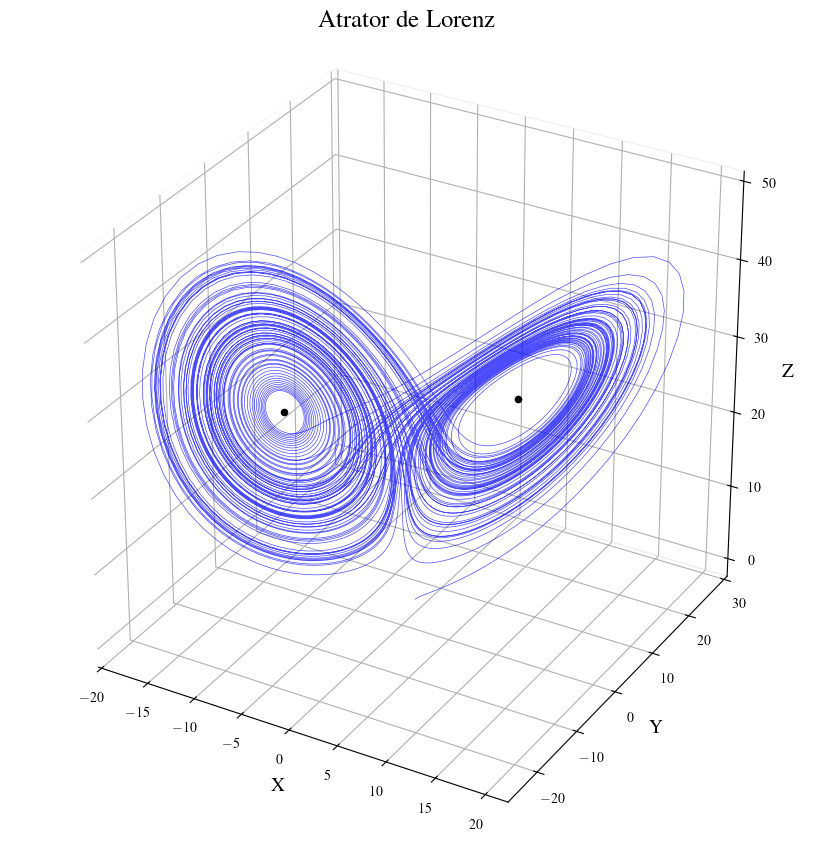

In [3]:
# ============================================================================
# Código para plotar o sistema de Lorenz
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Versão 1.1
# ============================================================================

print("\n" + "=" * 70)
print('Gráfico 3D do atrator de Lorenz')
print('gráfico salvo como: lorenz_3d.pdf')
print("=" * 70)

# 1. Criar figura 3D
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1,1,1])  # Mantém proporção 3D
fig.tight_layout(rect=[0, 0, 0.95, 0.9])  # Ajuste principal aqui

# 2. Plotar trajetória 3D

ax.plot(x_vals, y_vals, z_vals, 'b-', alpha=0.7, linewidth=0.5)

x_1, y_1, z = 1.8708, 1.8708, 14

# Usando scatter (recomendado para pontos isolados)
#ax.scatter(x_1, y_1, z_1, color='red', s=50, label='Ponto $P_{+}$')
ax.scatter(pf[0]*-1,pf[1]*-1,pf[2], color='black', s=20, label='Ponto fixo $P_{-}$')
ax.scatter(pf[0],pf[1],pf[2], color='black', s=20, label='Ponto fixo $P_{-}$')
ax.set_xlabel(r'X', fontsize=14, fontname='Times New Roman')
ax.xaxis.pane.fill = False
ax.set_ylabel(r'Y', fontsize=14, fontname='Times New Roman')
ax.yaxis.pane.fill = False
ax.set_zlabel(r'Z', fontsize=14, fontname='Times New Roman')
ax.zaxis.pane.fill = False
ax.set_title('Atrator de Lorenz', fontsize=18, fontname='Times New Roman', fontweight='bold')


# 3. Adicionar grade e estilo
ax.grid(True, alpha=0.3, linewidth=0.009, color='black')
# Ajustar layout
fig.tight_layout(rect=[0, 0.05, 0.85, 0.9])

# 4. Salvar figura
#plt.savefig("at1.pdf",dpi=300, transparent=True,bbox_inches='tight')
fig.savefig('lorenz_3d.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### **3.2.** Código com os pontos fixos estáveis


Gráfico 3D do atrator de Lorenz
FIGURA GERADA COM SUCESSO! Gráfico salvo como: l3d.pdf


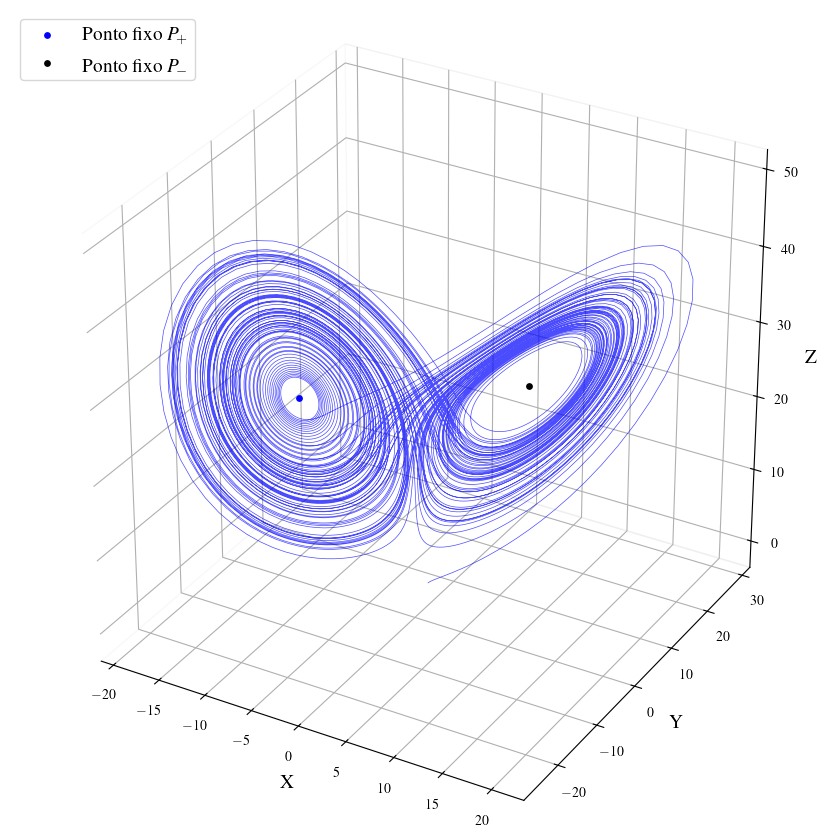

In [4]:
# ==========================================================================================
# Código para plotar o sistema de Lorenz (versão revisada)
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Versão 1.2 – Ajustes: grade fina preta, enquadramento do atrator, legenda P+ e P-
# ==========================================================================================

print("\n" + "=" * 80)
print('Gráfico 3D do atrator de Lorenz')

# 1. Criar figura 3D
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1, 1, 1])  # Mantém proporção 3D

# 2. Plotar trajetória 3D (mantida exatamente como no original)
ax.plot(x_vals, y_vals, z_vals, 'b-', alpha=0.7, linewidth=0.5)

# 3. Pontos fixos

# 3.1 Ponto fixo positivo (P+)

ax.scatter(pf[0], pf[1], pf[2], color='blue', s=15, label=r'Ponto fixo $P_{+}$')#, edgecolors='black', linewidth=0.5)

# 3.2 Ponto fixo negativo (P-): coordenadas (-x, -y, +z)

ax.scatter(-pf[0], -pf[1], pf[2], color='black', s=15, label=r'Ponto fixo $P_{-}$')#, edgecolors='black', linewidth=0.5)

# 4. Rótulos dos eixos com fonte Times New Roman

ax.set_xlabel(r'X', fontsize=14, fontname='Times New Roman')
ax.xaxis.pane.fill = False
ax.set_ylabel(r'Y', fontsize=14, fontname='Times New Roman')
ax.yaxis.pane.fill = False
ax.set_zlabel(r'Z', fontsize=14, fontname='Times New Roman')
ax.zaxis.pane.fill = False
#ax.set_title('Atrator de Lorenz', fontsize=18, fontname='Times New Roman', fontweight='bold')
x_min, x_max = min(x_vals), max(x_vals)
y_min, y_max = min(y_vals), max(y_vals)
z_min, z_max = min(z_vals), max(z_vals)
# Adiciona uma margem de 10%
margin = 0.1
ax.set_xlim(x_min - margin*(x_max-x_min), x_max + margin*(x_max-x_min))
ax.set_ylim(y_min - margin*(y_max-y_min), y_max + margin*(y_max-y_min))
ax.set_zlim(z_min - margin*(z_max-z_min), z_max + margin*(z_max-z_min))
ax.grid(True, linestyle='-', linewidth=0.2, color='black')
ax.legend(fontsize=14, loc='upper left', frameon=True)
fig.tight_layout(rect=[0, 0.05, 0.85, 0.9])

# 5. Comandos e configurações para salvar a figura:
print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: l3d.pdf')
print("=" * 80)
fig.savefig('l3d.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()



## **04.** Projeções do sistema

Esta parte do código gera as projeções do sistema nos planos:

1. Projeção $XY$;
2. Projeção $XZ$;
3. Projeção $YZ$.

### **4.1.** Projeção $XY$


GERANDO PROJEÇÃO XY DO ATRATOR DE LORENZ...
Gráfico salvo como: 'lpxy.pdf'
FIGURA GERADA COM SUCESSO! Gráfico salvo como: lpxy.pdf


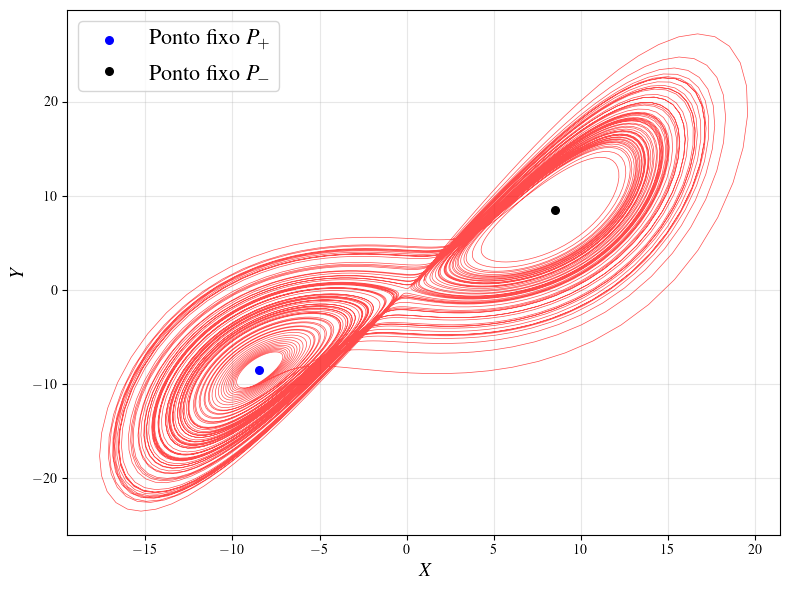

In [5]:
# ==========================================================================================
# Código para plotar o sistema de Lorenz (versão revisada)
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Código: PROJEÇÃO XY DO ATRATOR DE LORENZ
# Última atualização: 19/02/2026
# ==========================================================================================

print("\n" + "=" * 80)
print("GERANDO PROJEÇÃO XY DO ATRATOR DE LORENZ...")
print("Gráfico salvo como: 'lpxy.pdf'")
print("=" * 80)

# 1. Criar figura

fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plotar projeção XY
ax.plot(x_vals, y_vals, 'r-', alpha=0.7, linewidth=0.5)
ax.set_xlabel(r'$X$', fontsize=14, fontname='Times New Roman')
ax.set_ylabel(r'$Y$', fontsize=14, fontname='Times New Roman')
#ax.set_title('Projeção XY do Atrator de Lorenz', fontsize=16, fontname='Times New Roman', fontweight='bold')

# 3. Plotar os pontos fixos

plt.scatter(pf[0], pf[1], color='blue', s=30, label='Ponto fixo $P_{+}$')
plt.scatter(-pf[0], -pf[1], color='black', s=30, label='Ponto fixo $P_{-}$')

# 4. Configurações do gráfico

ax.grid(True, alpha=0.3)
ax.legend(fontsize=16)
fig.tight_layout()

# 5. Comandos para salvar a figura
print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: lpxy.pdf')
print("=" * 80)

fig.savefig('lpxy.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### **4.2.** Projeção $XZ$


GERANDO PROJEÇÃO XZ DO ATRATOR DE LORENZ
Gráfico salvo como: 'lpxz.pdf'
FIGURA GERADA COM SUCESSO! Gráfico salvo como: lpxz.pdf


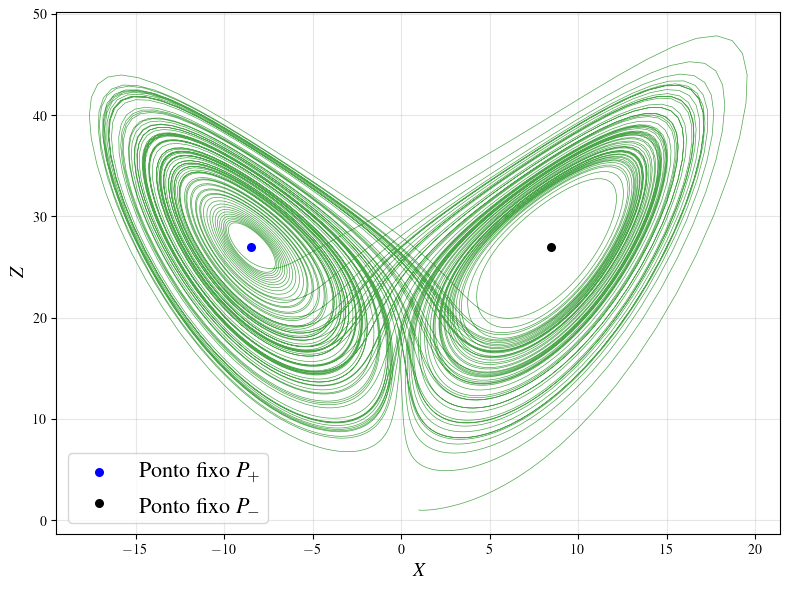

In [6]:
# ==========================================================================================
# Código para plotar o sistema de Lorenz (versão revisada)
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Código: PROJEÇÃO XZ DO ATRATOR DE LORENZ
# Última atualização: 19/02/2026
# ==========================================================================================

print("\n" + "=" * 80)
print("GERANDO PROJEÇÃO XZ DO ATRATOR DE LORENZ")
print("Gráfico salvo como: 'lpxz.pdf'")
print("=" * 80)

# 1. Criar figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plotar projeção XZ

ax.plot(x_vals, z_vals, 'g-', alpha=0.7, linewidth=0.5)
ax.set_xlabel(r'$X$', fontsize=14)
ax.set_ylabel(r'$Z$', fontsize=14)
#ax.set_title('Projeção XZ do Atrator de Lorenz', fontsize=16, fontname='Times New Roman', fontweight='bold')

# 3. Plotar os pontos fixos

plt.scatter(pf[0], pf[2], color='blue', s=30, label='Ponto fixo $P_{+}$')
plt.scatter(-pf[0], pf[2], color='black', s=30, label='Ponto fixo $P_{-}$')

# Configurações do Gráfico

ax.grid(True, alpha=0.3)
fig.tight_layout()
ax.legend(fontsize=16)

# 5. Configurações para salvar a figura

print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: lpxz.pdf')
print("=" * 80)
fig.savefig('lpxz.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### **4.3.** Projeção $YZ$


GERANDO PROJEÇÃO YZ DO ATRATOR DE LORENZ
Gráfico salvo como: 'lpyz.pdf'
FIGURA GERADA COM SUCESSO! Gráfico salvo como: lpyz.pdf


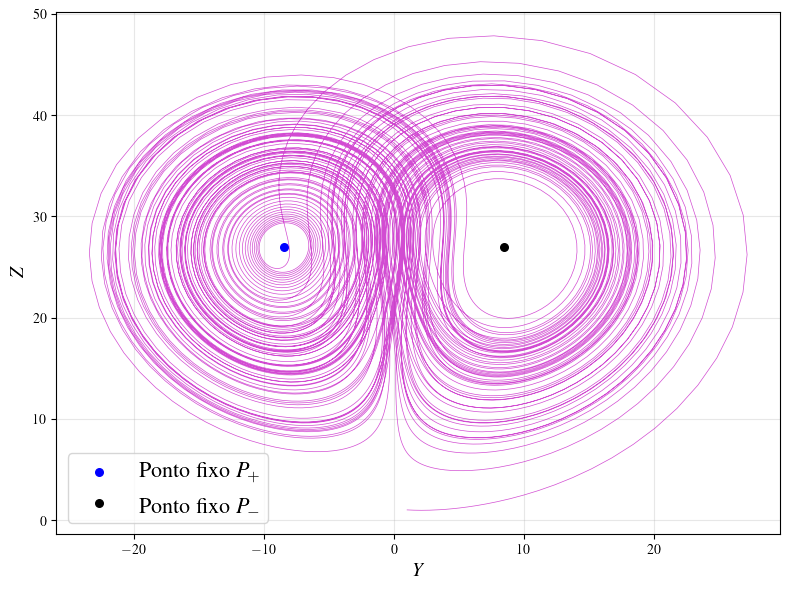

In [8]:
# ==========================================================================================
# Código para plotar o sistema de Lorenz (versão revisada)
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Código: PROJEÇÃO YZ DO ATRATOR DE LORENZ
# Última atualização: 19/02/2026
# ==========================================================================================

print("\n" + "=" * 80)
print("GERANDO PROJEÇÃO YZ DO ATRATOR DE LORENZ")
print("Gráfico salvo como: 'lpyz.pdf'")
print("=" * 80)

# 1. Criar figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plotar projeção YZ

ax.plot(y_vals, z_vals, 'm-', alpha=0.7, linewidth=0.5)
ax.set_xlabel(r'$Y$', fontsize=14, fontname='Times New Roman')
ax.set_ylabel(r'$Z$', fontsize=14, fontname='Times New Roman')
#ax.set_title('Projeção YZ do Atrator de Lorenz', fontsize=16, fontname='Times New Roman', fontweight='bold')

# 3. Plotar os pontos fixos

plt.scatter(pf[1], pf[2], color='blue', s=30, label='Ponto fixo $P_{+}$')
plt.scatter(-pf[1], pf[2], color='black', s=30, label='Ponto fixo $P_{-}$')

# 4. Configurações do gráfico

ax.grid(True, alpha=0.3)
fig.tight_layout()
ax.legend(fontsize=16)

# 5. Configurações para salvar a figura

print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: lpyz.pdf')
print("=" * 80)
fig.savefig('lpyz.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## **05.** Séries temporais

Essa parte do código gera as séries temporais para do sistema

### **5.1** Evolução temporal da função $X(t)$


GERANDO GRÁFICO: Séries temporais
Gráfico salvo como: 'xsol.pdf'
FIGURA GERADA COM SUCESSO! Gráfico salvo como: xsol.pdf


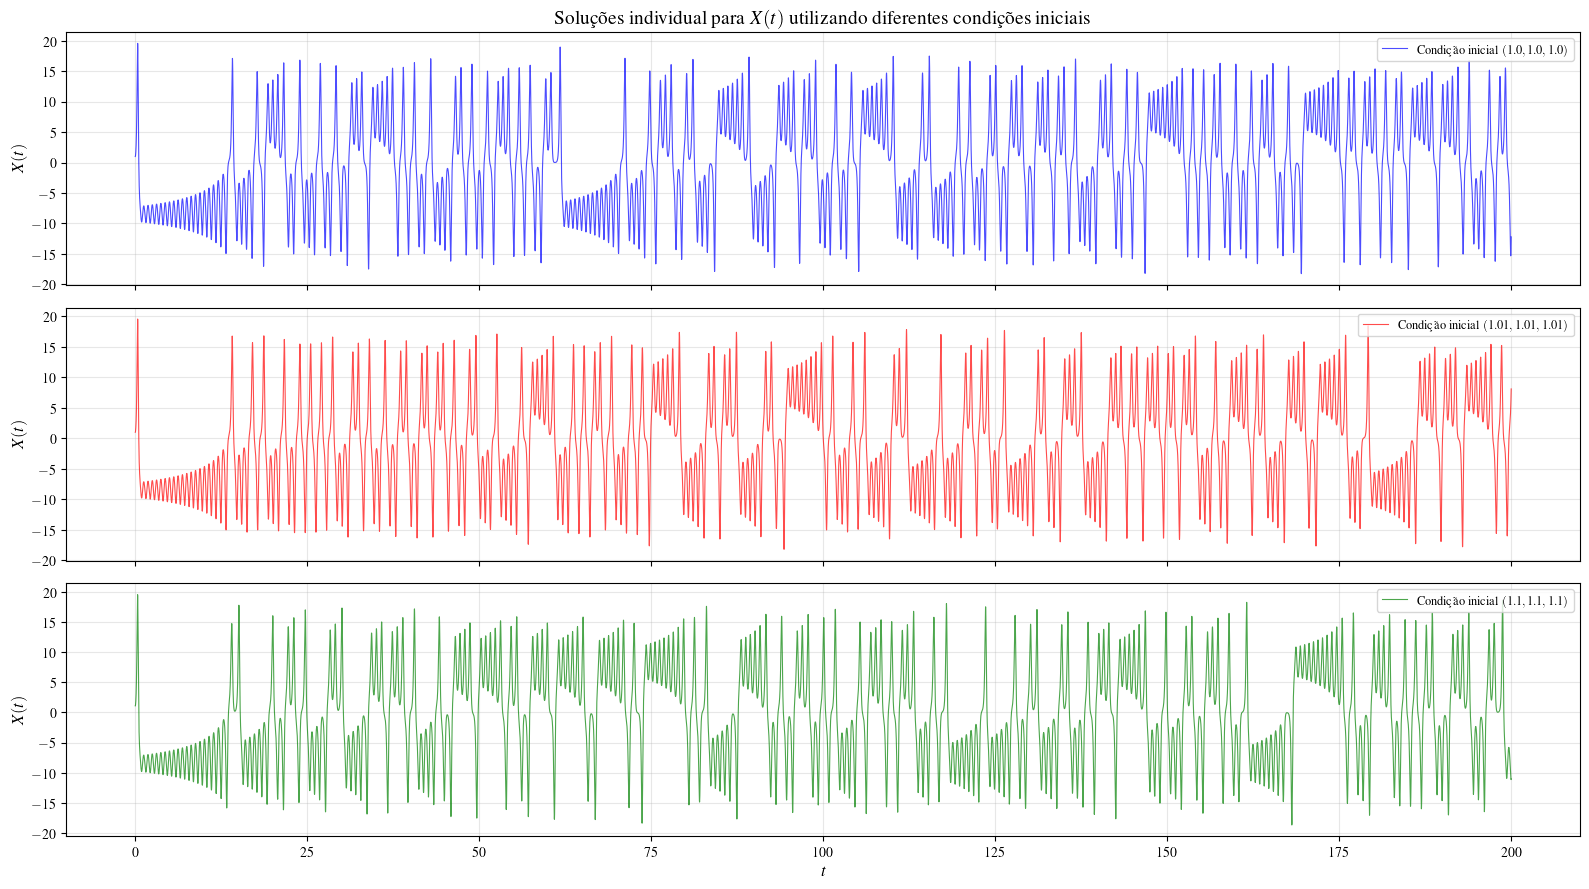

In [18]:
# ==========================================================================================
# Código para plotar o sistema de Lorenz (versão revisada)
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Código: Evolução temporal da função X(t)
# Última atualização: 19/02/2026
# ==========================================================================================


print("\n" + "=" * 80)
print("GERANDO GRÁFICO: Séries temporais")
print("Gráfico salvo como: 'xsol.pdf'")
print("=" * 80)

# 1. Parâmetros iniciais

estado_inicial_1 = [1.0, 1.0, 1.0]
estado_inicial_2 = [1.01, 1.01, 1.01]
estado_inicial_3 = [1.1, 1.1, 1.1]

t_span = (0, 1000)
t_eval = np.linspace(0, 200, 30000)

sol_1 = solve_ivp(lorenz, t_span, estado_inicial_1, t_eval=t_eval, rtol=1e-8)
x_vals_1, y_vals_1, z_vals_1 = sol_1.y
sol_2 = solve_ivp(lorenz, t_span, estado_inicial_2, t_eval=t_eval, rtol=1e-8)
x_vals_2, y_vals_2, z_vals_2 = sol_2.y
sol_3 = solve_ivp(lorenz, t_span, estado_inicial_3, t_eval=t_eval, rtol=1e-8)
x_vals_3, y_vals_3, z_vals_3 = sol_3.y

fig2, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# 2. Plot para as condições iniciais

# 2.1 Gráfico para (1,1,1)

axes[0].plot(t_eval, x_vals_1, 'b-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.0,1.0,1.0)$')
axes[0].set_ylabel(r'$X(t)$', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(r'Soluções individual para $X(t)$ utilizando diferentes condições iniciais', fontsize=14)
axes[0].legend(loc='upper right', fontsize=9)

# 2.2 Gráfico para (1.01,1.01,1.01)

axes[1].plot(t_eval, x_vals_2, 'r-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.01,1.01,1.01)$')
axes[1].set_ylabel(r'$X(t)$', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', fontsize=9)

# 2.3 Gráfico para (1.1,1.1,1.1)

axes[2].plot(t_eval, x_vals_3, 'g-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.1,1.1,1.1)$')
axes[2].set_ylabel(r'$X(t)$', fontsize=12)
axes[2].set_xlabel(r'$t$', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right', fontsize=9)

fig2.tight_layout()

# 3. Configurações para salvar a figura

print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: xsol.pdf')
print("=" * 80)
fig2.savefig('xsol.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### **5.2** Evolução temporal da função $Y(t)$


GERANDO GRÁFICO: Séries temporais
FIGURA GERADA COM SUCESSO! Gráfico salvo como: ysol.pdf


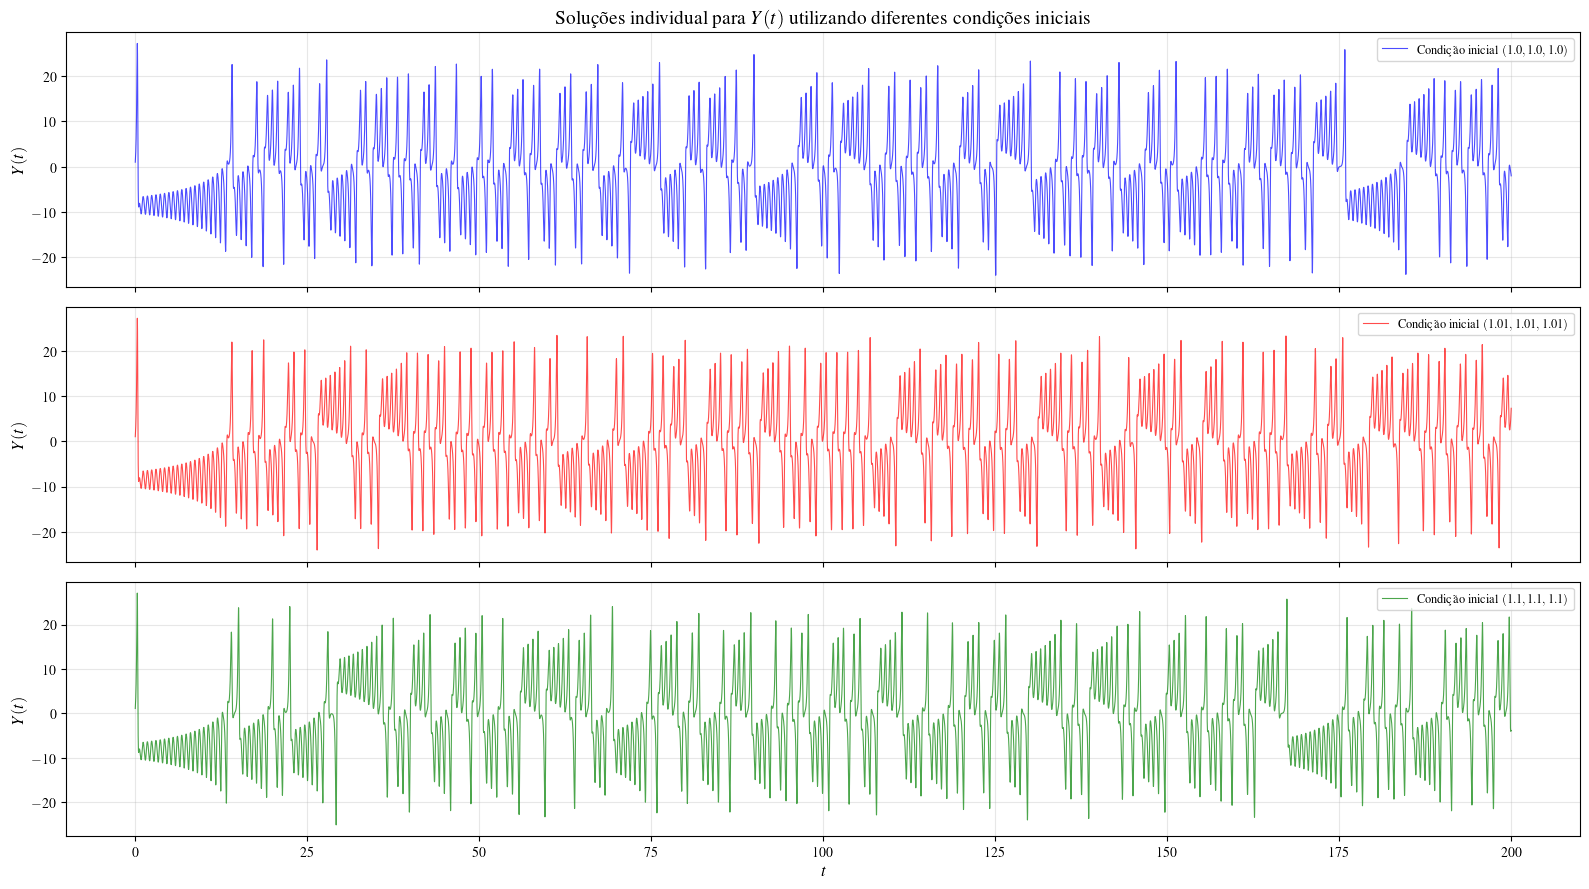

In [12]:
# ==========================================================================================
# Código para plotar o sistema de Lorenz (versão revisada)
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Código: Evolução temporal da função Y(t)
# Última atualização: 19/02/2026
# ==========================================================================================

print("\n" + "=" * 80)
print("GERANDO GRÁFICO: Séries temporais")

# 1. Parâmetros iniciais

estado_inicial_1 = [1.0, 1.0, 1.0]
estado_inicial_2 = [1.01, 1.01, 1.01]
estado_inicial_3 = [1.1, 1.1, 1.1]

t_span = (0, 1000)
t_eval = np.linspace(0, 200, 30000)

sol_1 = solve_ivp(lorenz, t_span, estado_inicial_1, t_eval=t_eval, rtol=1e-8)
x_vals_1, y_vals_1, z_vals_1 = sol_1.y

sol_2 = solve_ivp(lorenz, t_span, estado_inicial_2, t_eval=t_eval, rtol=1e-8)
x_vals_2, y_vals_2, z_vals_2 = sol_2.y

sol_3 = solve_ivp(lorenz, t_span, estado_inicial_3, t_eval=t_eval, rtol=1e-8)
x_vals_3, y_vals_3, z_vals_3 = sol_3.y


fig2, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# 2. Plot para as condições iniciais

# 2.1 Gráfico para (1,1,1)

axes[0].plot(t_eval, y_vals_1, 'b-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.0,1.0,1.0)$')
axes[0].set_ylabel(r'$Y(t)$', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(r'Soluções individual para $Y(t)$ utilizando diferentes condições iniciais', fontsize=14)
axes[0].legend(loc='upper right', fontsize=9)

# 2.2 Gráfico para (1.01,1.01,1.01)

axes[1].plot(t_eval, y_vals_2, 'r-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.01,1.01,1.01)$')
axes[1].set_ylabel(r'$Y(t)$', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', fontsize=9)

# 2.3 Gráfico para (1.1,1.1,1.1)

axes[2].plot(t_eval, y_vals_3, 'g-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.1,1.1,1.1)$')
axes[2].set_ylabel(r'$Y(t)$', fontsize=12)
axes[2].set_xlabel(r'$t$', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right', fontsize=9)

fig2.tight_layout()

# 3. Configurações para salvar a figura

print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: ysol.pdf')
print("=" * 80)
fig2.savefig('ysol.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### **5.3** Evolução temporal da função $Z(t)$


GERANDO GRÁFICO: Séries temporais
FIGURA GERADA COM SUCESSO! Gráfico salvo como: zsol.pdf


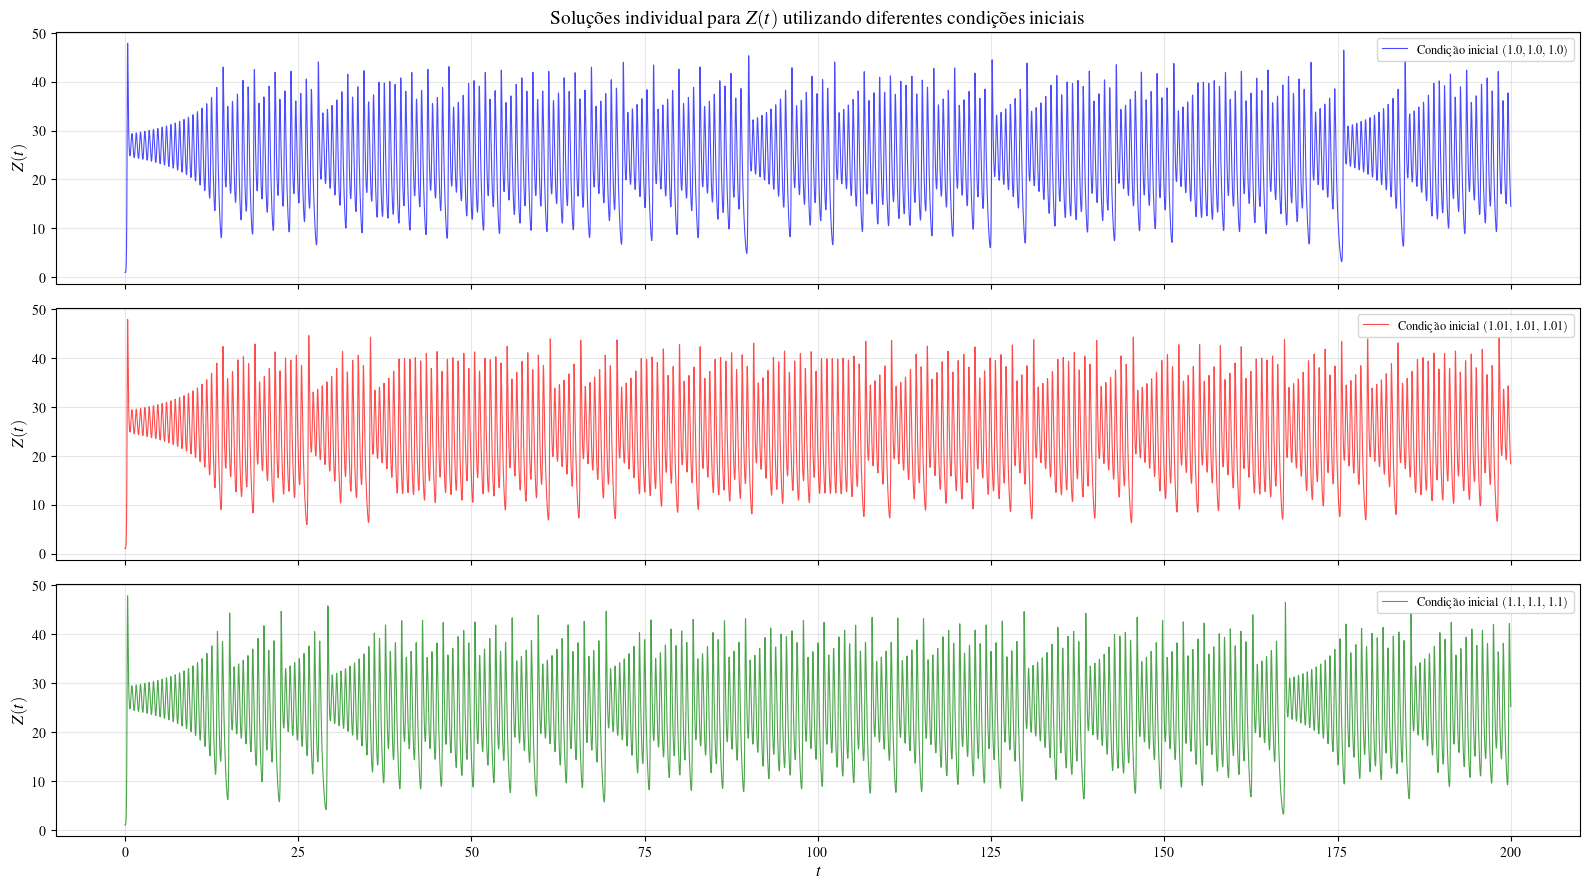

In [13]:
# ==========================================================================================
# Código para plotar o sistema de Lorenz (versão revisada)
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Código: Evolução temporal da função Z(t)
# Última atualização: 19/02/2026
# ==========================================================================================

print("\n" + "=" * 80)
print("GERANDO GRÁFICO: Séries temporais")

# 1. Parâmetros iniciais

estado_inicial_1 = [1.0, 1.0, 1.0]
estado_inicial_2 = [1.01, 1.01, 1.01]
estado_inicial_3 = [1.1, 1.1, 1.1]

t_span = (0, 1000)
t_eval = np.linspace(0, 200, 30000)

sol_1 = solve_ivp(lorenz, t_span, estado_inicial_1, t_eval=t_eval, rtol=1e-8)
x_vals_1, y_vals_1, z_vals_1 = sol_1.y

sol_2 = solve_ivp(lorenz, t_span, estado_inicial_2, t_eval=t_eval, rtol=1e-8)
x_vals_2, y_vals_2, z_vals_2 = sol_2.y

sol_3 = solve_ivp(lorenz, t_span, estado_inicial_3, t_eval=t_eval, rtol=1e-8)
x_vals_3, y_vals_3, z_vals_3 = sol_3.y


fig2, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

#2. Plot para as condições iniciais

# 2.1 Gráfico para (1,1,1)

axes[0].plot(t_eval, z_vals_1, 'b-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.0,1.0,1.0)$')
axes[0].set_ylabel(r'$Z(t)$', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(r'Soluções individual para $Z(t)$ utilizando diferentes condições iniciais', fontsize=14)
axes[0].legend(loc='upper right', fontsize=9)

# 2.2 Gráfico para (1.01,1.01,1.01)

axes[1].plot(t_eval, z_vals_2, 'r-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.01,1.01,1.01)$')
axes[1].set_ylabel(r'$Z(t)$', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', fontsize=9)

# 2.3 Gráfico para (1.1,1.1,1.1)

axes[2].plot(t_eval, z_vals_3, 'g-', alpha=0.7, linewidth=0.8, label='Condição inicial $(1.1,1.1,1.1)$')
axes[2].set_ylabel(r'$Z(t)$', fontsize=12)
axes[2].set_xlabel(r'$t$', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right', fontsize=9)

fig2.tight_layout()

# 3. Configurações para salvar a figura

print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: zsol.pdf')
print("=" * 80)
fig2.savefig('zsol.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## **06.** Espoente de Lyapunov

Esse código faz um cálculo simplificado do expoente de Lyapunov.


GERANDO GRÁFICO: Convergência do Expoente de Lyapunov...
Gráfico salvo como: 'lyapunov_convergencia.pdf'


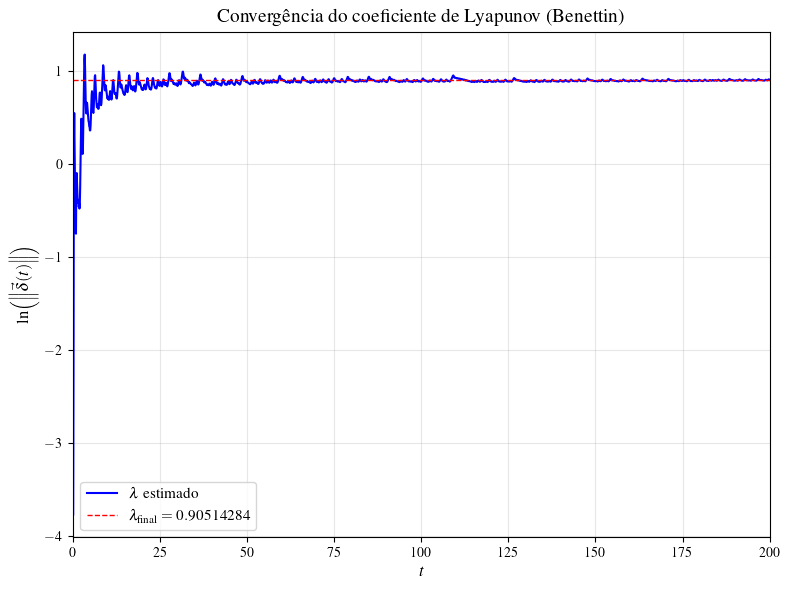

In [21]:
# ==========================================================================================
# Código para plotar a convergência do expoente de Lyapunov (Método de Benettin)
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Última atualização: 13/03/2026
#     > Correção de incopatibilidade
# ==========================================================================================

import numpy as np
import matplotlib.pyplot as plt

print("\n" + "=" * 80)
print("GERANDO GRÁFICO: Convergência do Expoente de Lyapunov...")

# 1. Verificar se as variáveis do cálculo de Benettin estão disponíveis
if 'tempos_lyap' in locals() and 'lyap_running' in locals() and len(tempos_lyap) > 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plotar estimativa corrente do expoente
    ax.plot(tempos_lyap, lyap_running, 'b-', linewidth=1.5, 
            label=r'$\lambda$ estimado')
    
    # Linha horizontal com o valor final
    ax.axhline(y=expoente_lyapunov, color='r', linestyle='--', linewidth=1,
               label=rf'$\lambda_{{\text{{final}}}} = {expoente_lyapunov:.8f}$')
    
    # Configurar eixos e título
    ax.set_xlabel(r'$t$', fontsize=12)
    ax.set_ylabel(r'$\ln(\norm{\vec{\delta}(t)})$', fontsize=12)
    ax.set_title(r'Convergência do coeficiente de Lyapunov (Benettin)', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Ajustar limites
    ax.set_xlim(0, tempos_lyap[-1])
    
    fig.tight_layout()
    
    # Salvar figura
    fig.savefig('lyapunov_convergencia.pdf', dpi=300, bbox_inches='tight', transparent=True)
    print("Gráfico salvo como: 'lyapunov_convergencia.pdf'")
    print("=" * 80)
    plt.show()
else:
    print("Atenção: Dados de convergência do expoente de Lyapunov não encontrados.")
    print("Certifique-se de que o cálculo de Benettin (Código 02) foi executado e")
    print("armazenou 'tempos_lyap' e 'lyap_running'.")
    print("=" * 80)

## **07.** Código para gerar o gráfico da introdução


GERANDO PROJEÇÃO XZ DO ATRATOR DE LORENZ
Gráfico salvo como: 'lorenz_projecao_xz.pdf'
FIGURA GERADA COM SUCESSO! Gráfico salvo como: zsol.pdf


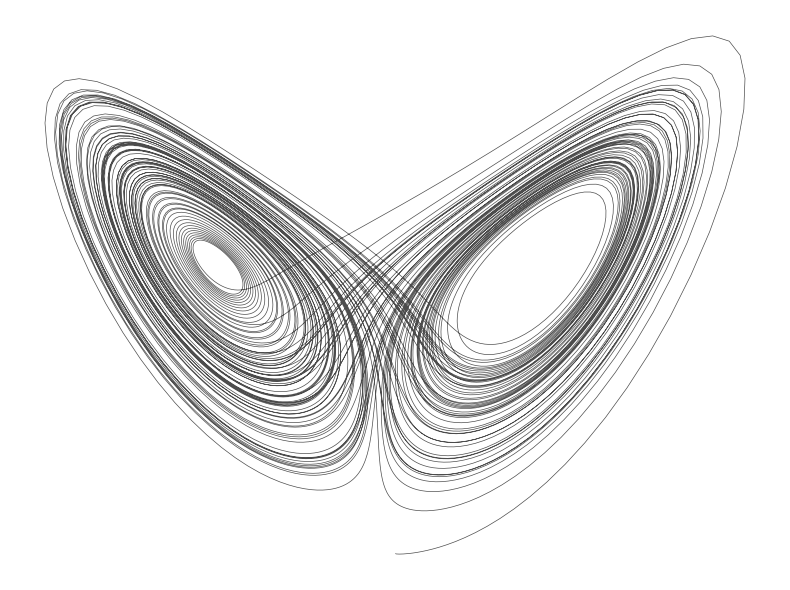

In [22]:
# ==========================================================================================
# Código: PROJEÇÃO XZ DO ATRATOR DE LORENZ
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Última atualização: 19/02/2026
# ==========================================================================================

print("\n" + "=" * 60)
print("GERANDO PROJEÇÃO XZ DO ATRATOR DE LORENZ")
print("Gráfico salvo como: 'lorenz_projecao_xz.pdf'")
print("=" * 60)

# 1. Criar figura
fig, ax = plt.subplots(figsize=(8, 6))

# Plotar projeção XZ
ax.plot(x_vals, z_vals, color='black', alpha=0.7, linewidth=0.5)
#ax.set_xlabel(r'$X$', fontsize=14)
#ax.set_ylabel(r'$Z$', fontsize=14)
#ax.set_title('Projeção XZ do Atrator de Lorenz', fontsize=16, 
#             fontname='Times New Roman', fontweight='bold')

#ax.set_xticks([])
#ax.set_yticks([])
ax.axis('off')


# 2. Adicionar grade
ax.grid(True, alpha=0.3)

# 3. Ajustar layout
fig.tight_layout()

# 4. Configurações para salvar a figura

print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: zsol.pdf')
print("=" * 80)
fig.savefig('lorenz_projecao_transp.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## **08.** análise do sistema de Maxwell-Bloch reduzido

### **8.1.** Sistema completo


Sistema de Maxwell-Bloch reduzido: análise completa
FIGURA GERADA COM SUCESSO! Gráfico salvo como: mbreduzido2.pdf


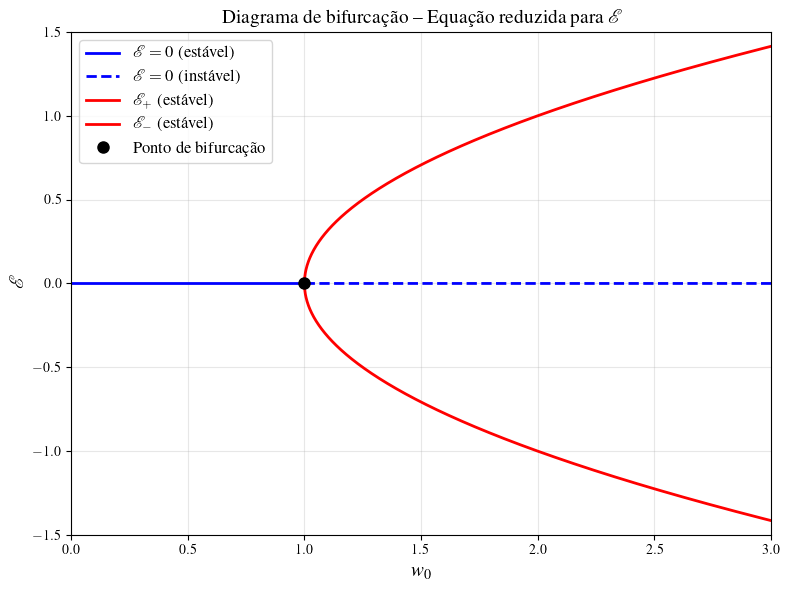

In [24]:
# ==========================================================================================
# Código: Análise do sistema de Maxwell-Bloch Reduzido
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Última atualização: 19/02/2026
# ==========================================================================================

print("\n" + "=" * 80)
print('Sistema de Maxwell-Bloch reduzido: análise completa')

# 1. Parâmetros fixos (ajustáveis)

gamma1 = 1.0
gamma2 = 1.0
kappa = 1.0
g0 = 1.0
kappa_c = 1.0

# 2. Parâmetro de bifurcação: w0

w0_min = 0.0
w0_max = 3.0
w0 = np.linspace(w0_min, w0_max, 2000)

# 3. Ponto de bifurcação (condição para ramos não triviais)

w0_crit = gamma2 * kappa_c / (g0 * kappa)   # = 1.0 com os valores acima

# Ramo trivial: E = 0
# Estável quando w0 < w0_crit, instável quando w0 > w0_crit
E0 = np.zeros_like(w0)

# 4. Separa as regiões estável e instável para plotar com estilos diferentes

mask_stable = w0 < w0_crit
mask_unstable = w0 > w0_crit

# Ramos não triviais: existem apenas para w0 > w0_crit
# Expressão: E = ± sqrt( (gamma1*gamma2/kappa**2) * (g0*kappa*w0/(gamma2*kappa_c) - 1) )
# Para w0 <= w0_crit, não definimos (usaremos NaN)
E_nontrivial_pos = np.where(w0 > w0_crit,
                            np.sqrt((gamma1 * gamma2 / kappa**2) *
                                    (g0 * kappa * w0 / (gamma2 * kappa_c) - 1)),
                            np.nan)
E_nontrivial_neg = -E_nontrivial_pos

# 5. Configuração do gráfico
plt.figure(figsize=(8, 6))

# 5.1 Ramo trivial: estável (linha sólida) e instável (linha tracejada)
plt.plot(w0[mask_stable], E0[mask_stable], 'b-', linewidth=2, label=r'$\mathcal{E}=0$ (estável)')
plt.plot(w0[mask_unstable], E0[mask_unstable], 'b--', linewidth=2, label=r'$\mathcal{E}=0$ (instável)')

# 5.2 Ramos não triviais: sempre estáveis (linha sólida)
plt.plot(w0, E_nontrivial_pos, 'r-', linewidth=2, label=r'$\mathcal{E}_+$ (estável)')
plt.plot(w0, E_nontrivial_neg, 'r-', linewidth=2, label=r'$\mathcal{E}_-$ (estável)')

# 5.3 Destaca o ponto de bifurcação
plt.plot(w0_crit, 0, 'ko', markersize=8, label='Ponto de bifurcação')

# 6. Configuração do gráfico

plt.xlabel(r'$w_0$', fontsize=14)
plt.ylabel(r'$\mathcal{E}$', fontsize=14)
plt.title('Diagrama de bifurcação – Equação reduzida para $\mathcal{E}$', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=12)
plt.xlim(w0_min, w0_max)
plt.ylim(-1.5, 1.5)

# 5. Configurações para salvar a figura

print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: mbreduzido2.pdf')
print("=" * 80)
plt.savefig('mbreduzido2.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()

### **8.2.** Sistema com interpretação física


Sistema de Maxwell-Bloch Reduzido - Análise física
FIGURA GERADA COM SUCESSO! Gráfico salvo como: mbreduzido2.pdf


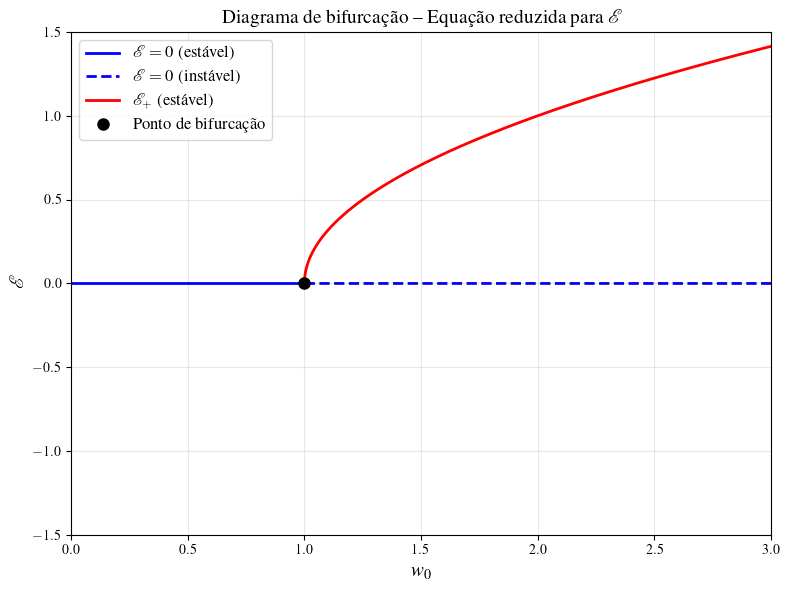

In [25]:
# ==========================================================================================
# Código: Análise do sistema de Maxwell-Bloch Reduzido
# Autor: Jimi (Willian Bonner)
# Data de criação: 04/02/2026
# Última atualização: 19/02/2026
# ==========================================================================================

print("\n" + "=" * 70)
print('Sistema de Maxwell-Bloch Reduzido - Análise física')

# 1. Parâmetros fixos (ajustáveis)

gamma1 = 1.0
gamma2 = 1.0
kappa = 1.0
g0 = 1.0
kappa_c = 1.0

# 2. Parâmetro de bifurcação: w0

w0_min = 0.0
w0_max = 3.0
w0 = np.linspace(w0_min, w0_max, 2000)

# 3. Ponto de bifurcação (condição para ramos não triviais)

w0_crit = gamma2 * kappa_c / (g0 * kappa)   # = 1.0 com os valores acima

# Ramo trivial: E = 0
# Estável quando w0 < w0_crit, instável quando w0 > w0_crit
E0 = np.zeros_like(w0)

# 4. Separa as regiões estável e instável para plotar com estilos diferentes

mask_stable = w0 < w0_crit
mask_unstable = w0 > w0_crit

# Ramos não triviais: existem apenas para w0 > w0_crit
# Expressão: E = ± sqrt( (gamma1*gamma2/kappa**2) * (g0*kappa*w0/(gamma2*kappa_c) - 1) )
# Para w0 <= w0_crit, não definimos (usaremos NaN)
E_nontrivial_pos = np.where(w0 > w0_crit,
                            np.sqrt((gamma1 * gamma2 / kappa**2) *
                                    (g0 * kappa * w0 / (gamma2 * kappa_c) - 1)),
                            np.nan)
E_nontrivial_neg = -E_nontrivial_pos

# 5. Configuração do gráfico
plt.figure(figsize=(8, 6))

# 5.1 Ramo trivial: estável (linha sólida) e instável (linha tracejada)
plt.plot(w0[mask_stable], E0[mask_stable], 'b-', linewidth=2, label=r'$\mathcal{E}=0$ (estável)')
plt.plot(w0[mask_unstable], E0[mask_unstable], 'b--', linewidth=2, label=r'$\mathcal{E}=0$ (instável)')

# 5.2 Ramos não triviais: sempre estáveis (linha sólida)
plt.plot(w0, E_nontrivial_pos, 'r-', linewidth=2, label=r'$\mathcal{E}_+$ (estável)')
#plt.plot(w0, E_nontrivial_neg, 'r-', linewidth=2, label=r'$\mathcal{E}_-$ (estável)')

# 5.3 Destaca o ponto de bifurcação
plt.plot(w0_crit, 0, 'ko', markersize=8, label='Ponto de bifurcação')

# 6. Configuração do gráfico

plt.xlabel(r'$w_0$', fontsize=14)
plt.ylabel(r'$\mathcal{E}$', fontsize=14)
plt.title('Diagrama de bifurcação – Equação reduzida para $\mathcal{E}$', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=12)
plt.xlim(w0_min, w0_max)
plt.ylim(-1.5, 1.5)

# 5. Configurações para salvar a figura

print('FIGURA GERADA COM SUCESSO! Gráfico salvo como: mbreduzido2.pdf')
print("=" * 80)
plt.savefig('mbreduzido2.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()

## **09.** Verificação final

Antes de subir o código para o Github, fiz um teste de compilação utilizando o Jupyter Notebook do Anaconda Navigator em 13 de Março de 2026.

Está tudo funcionando corretamente.